# Реализация интерполяционного многочлена Ньютона

В данной программе я реализую алгоритм построения интерполяционного многочлена Ньютона $P_n(x)$ для заданных функций на отрезке $[a, b]$ с использованием равноотстоящих и чебышевских узлов. Вычисление значений многочлена будет производиться с помощью схемы Горнера.

**Мой вариант (№11):**
1. $f_1(x) = \cos(2x)$
2. $f_2(x) = \sin|x| + 1$
Отрезок: $[a, b] =[-2, 2]$

Для начала импортирую необходимые библиотеки и задам исходные функции.

In [16]:
import numpy as np
import matplotlib.pyplot as plt
import warnings

# Отключаем предупреждения об overflow, так как при высоких степенях n 
# вычисление разделенных разностей на равноотстоящей сетке математически неустойчиво
warnings.filterwarnings('ignore')

# Задаю функции моего варианта
def f1(x):
    return np.cos(2 * x)

def f2(x):
    return np.sin(np.abs(x)) + 1

# Интервал
A, B = -2.0, 2.0

# Массив из 501 точки для построения гладких графиков
x_plot = np.linspace(A, B, 501)

### 1. Выбор узлов интерполирования

Точность интерполирования существенно зависит от выбора узлов. Я реализую два способа генерации сетки:

1. **Равноотстоящие узлы:**
   $$x_i = a + i \frac{b - a}{n}, \quad i = 0, \dots, n$$

2. **Чебышевские узлы:**
   Для минимизации остатка интерполирования в качестве узлов лучше брать корни многочлена Чебышева.
   $$x_i = \frac{a + b}{2} + \frac{b - a}{2} \cos\left(\frac{(2i + 1)\pi}{2(n + 1)}\right), \quad i = 0, \dots, n$$

In [17]:
def get_equidistant_nodes(a, b, n):
    """Возвращает n+1 равноотстоящих узлов на отрезке [a, b]"""
    i = np.arange(n + 1)
    return a + i * (b - a) / n

def get_chebyshev_nodes(a, b, n):
    """Возвращает n+1 чебышевских узлов на отрезке [a, b]"""
    i = np.arange(n + 1)
    return (a + b) / 2 + (b - a) / 2 * np.cos((2 * i + 1) * np.pi / (2 * (n + 1)))

### 2. Разделенные разности и форма Ньютона

Для построения многочлена я буду использовать аппарат разделенных разностей. 
Разделенная разность первого порядка определяется как:
$$f(x_i, x_j) = \frac{f(x_j) - f(x_i)}{x_j - x_i}$$

Многочлен в форме Ньютона записывается через них:
$$P_n(x) = f(x_0) + (x - x_0)f(x_0, x_1) + \dots + (x - x_0)\dots(x - x_{n-1})f(x_0, \dots, x_n)$$

Чтобы эффективно вычислить значение этого полинома в заданной точке $x$, я применю **схему Горнера**. Суть в том, чтобы выносить общий множитель $(x - x_i)$, начиная со старшей разделенной разности, двигаясь с конца:
$$P_n(x) = f(x_0) + (x - x_0)\Big(f(x_0, x_1) + (x - x_1)\big( \dots + (x - x_{n-1})f(x_0, \dots, x_n)\big)\Big)$$

In [18]:
def get_divided_differences(x_nodes, y_nodes):
    """Вычисляет разделенные разности и возвращает коэффициенты для полинома Ньютона"""
    n = len(x_nodes)
    coef = np.zeros([n, n])
    coef[:, 0] = y_nodes
    
    # Заполняем таблицу разделенных разностей
    for j in range(1, n):
        for i in range(n - j):
            coef[i][j] = (coef[i + 1][j - 1] - coef[i][j - 1]) / (x_nodes[i + j] - x_nodes[i])
            
    # Нас интересует только верхняя строка: f(x0), f(x0,x1), f(x0,x1,x2)...
    return coef[0, :]

def newton_poly_horner(coef, x_nodes, x):
    """Вычисляет значение многочлена Ньютона в точках x по схеме Горнера"""
    n = len(coef) - 1
    # Начинаем со старшего коэффициента
    result = coef[n]
    
    # Идем в обратном порядке от n-1 до 0
    for i in range(n - 1, -1, -1):
        result = result * (x - x_nodes[i]) + coef[i]
        
    return result

### 3. Вычислительный эксперимент: Построение графиков

Здесь я построю совмещенные графики исходных функций $f_1(x), f_2(x)$ и их интерполяционных многочленов $P_n(x)$ для степеней $n = 2, 10, 20$.
Вычисления будут проведены как для равноотстоящих, так и для чебышевских узлов (итого 12 графиков).

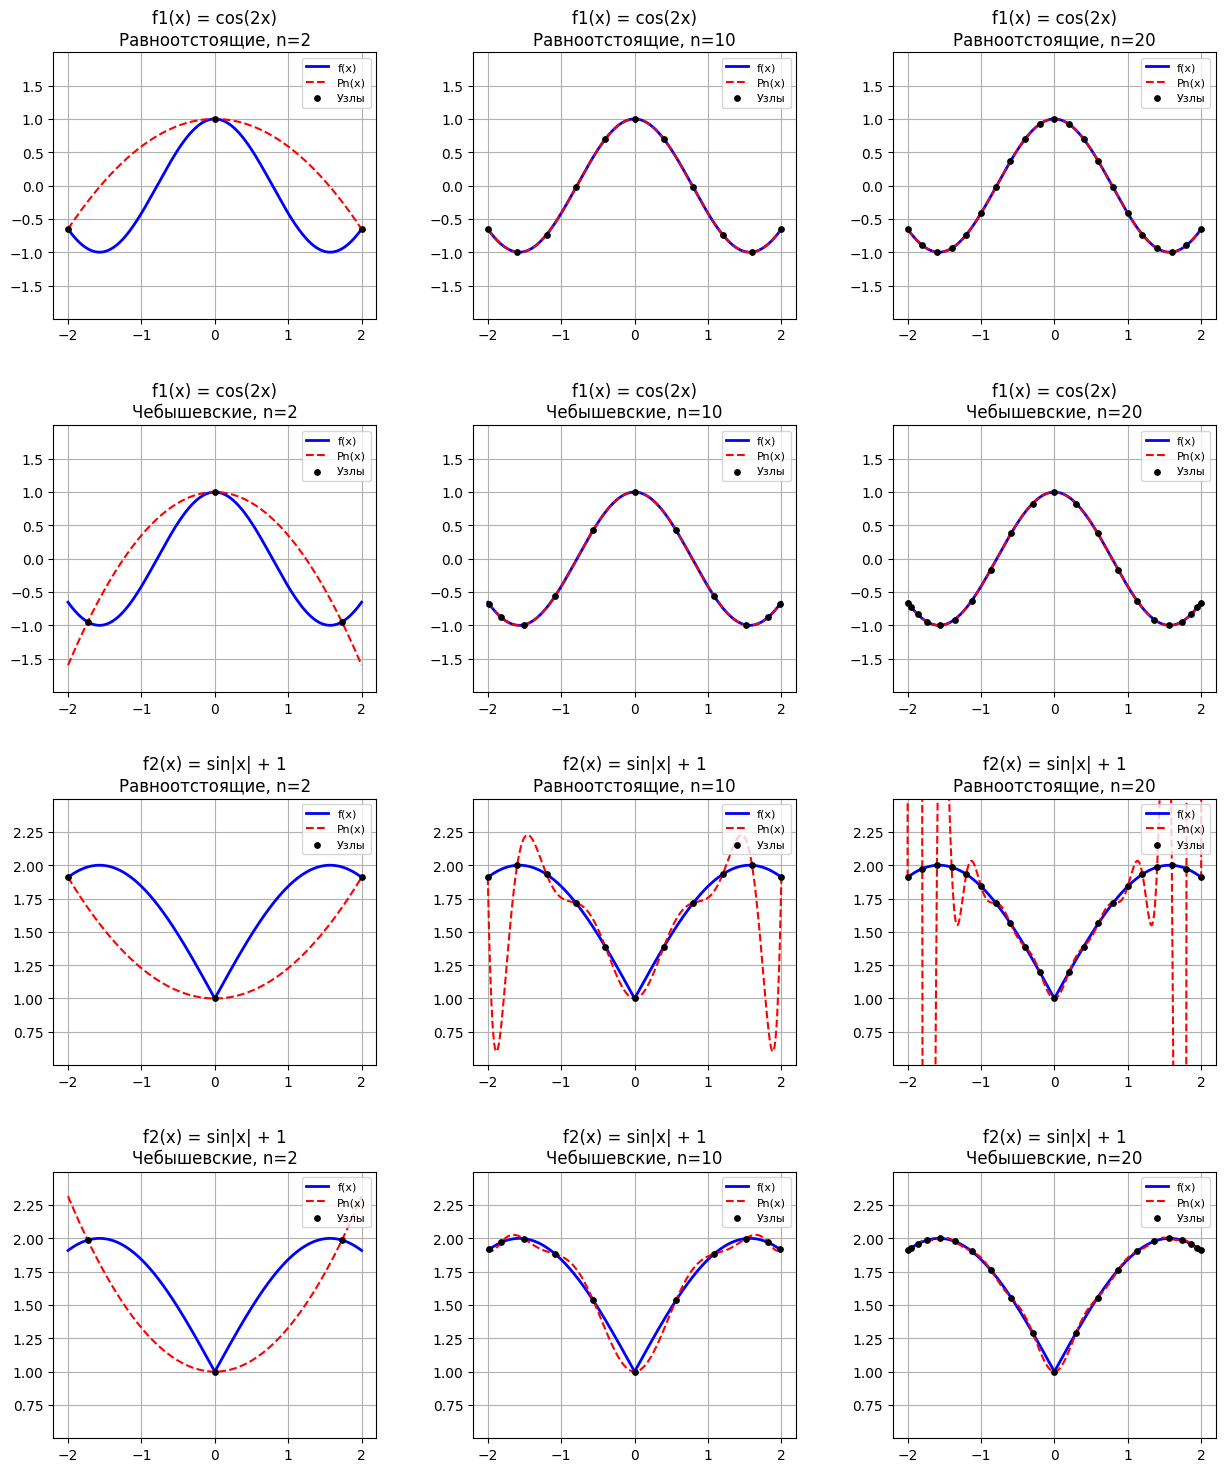

In [19]:
degrees = [2, 10, 20]
functions =[(f1, 'f1(x) = cos(2x)'), (f2, 'f2(x) = sin|x| + 1')]
node_types =[('Равноотстоящие', get_equidistant_nodes), 
              ('Чебышевские', get_chebyshev_nodes)]

fig, axes = plt.subplots(4, 3, figsize=(15, 18))
fig.subplots_adjust(hspace=0.4, wspace=0.3)

plot_row = 0

for func, func_name in functions:
    y_plot_true = func(x_plot) # Истинные значения функции
    
    for node_name, node_func in node_types:
        for j, n in enumerate(degrees):
            ax = axes[plot_row, j]
            
            # 1. Генерирую узлы и считаю значения функции
            x_nodes = node_func(A, B, n)
            y_nodes = func(x_nodes)
            
            # 2. Вычисляю разделенные разности
            coefs = get_divided_differences(x_nodes, y_nodes)
            
            # 3. Вычисляю значения многочлена по схеме Горнера для графика
            y_poly = newton_poly_horner(coefs, x_nodes, x_plot)
            
            # Отрисовка
            ax.plot(x_plot, y_plot_true, label='f(x)', color='blue', lw=2)
            ax.plot(x_plot, y_poly, label=f'Pn(x)', color='red', linestyle='--')
            ax.scatter(x_nodes, y_nodes, color='black', zorder=5, label='Узлы', s=15)
            
            # Ограничиваю ось Y
            y_min, y_max = np.min(y_plot_true), np.max(y_plot_true)
            margin = (y_max - y_min) * 0.5
            ax.set_ylim(y_min - margin, y_max + margin)
            
            ax.set_title(f'{func_name}\n{node_name}, n={n}')
            ax.grid(True)
            ax.legend(loc='upper right', fontsize=8)
            
        plot_row += 1

plt.show()

### 4. Исследование сходимости интерполяционных процессов

Чтобы проанализировать сходимость, я построю график зависимости равномерной нормы погрешности от степени многочлена $n$. 
Норму погрешности определяю как максимальное отклонение на нашей сетке `x_plot`:
$$||r_n|| = \max_{i=0, \dots, 500} |P_n(\bar{x}_i) - f(\bar{x}_i)|$$
Степень $n$ изменяется от 1 до 61 с шагом 5. График строю в логарифмическом масштабе по оси ординат.

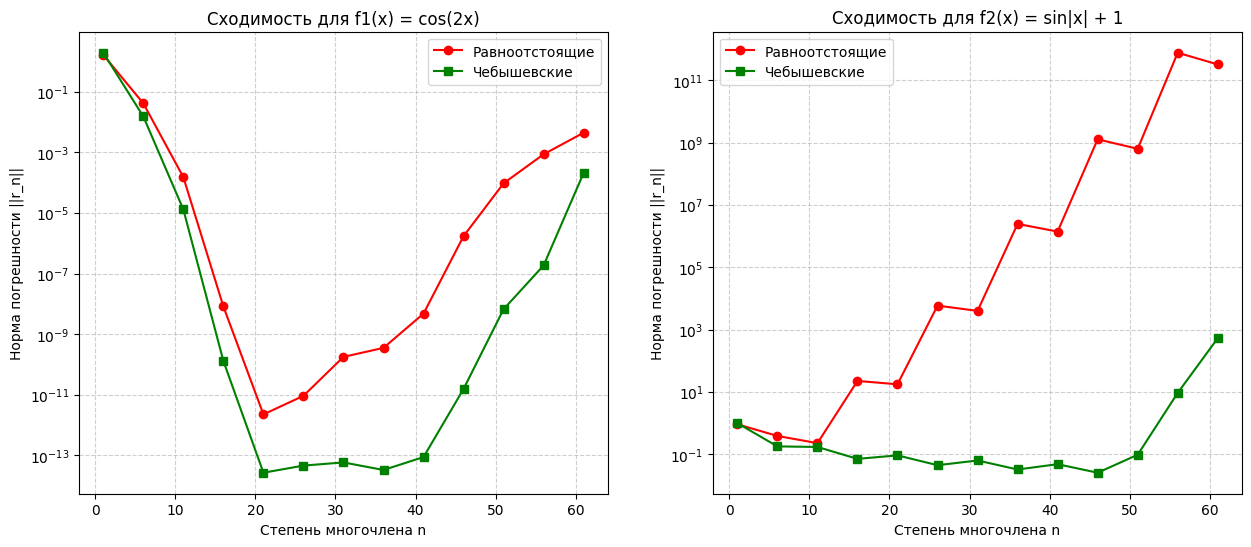

In [20]:
n_values = np.arange(1, 62, 5)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

for idx, (func, func_name) in enumerate(functions):
    y_plot_true = func(x_plot)
    
    errors_eq = []
    errors_cheb =[]
    
    for n in n_values:
        # Считаем норму для равноотстоящих узлов
        x_nodes_eq = get_equidistant_nodes(A, B, n)
        coefs_eq = get_divided_differences(x_nodes_eq, func(x_nodes_eq))
        y_poly_eq = newton_poly_horner(coefs_eq, x_nodes_eq, x_plot)
        err_eq = np.max(np.abs(y_poly_eq - y_plot_true))
        errors_eq.append(err_eq)
        
        # Считаем норму для чебышевских узлов
        x_nodes_cheb = get_chebyshev_nodes(A, B, n)
        coefs_cheb = get_divided_differences(x_nodes_cheb, func(x_nodes_cheb))
        y_poly_cheb = newton_poly_horner(coefs_cheb, x_nodes_cheb, x_plot)
        err_cheb = np.max(np.abs(y_poly_cheb - y_plot_true))
        errors_cheb.append(err_cheb)
        
    # Логарифмический масштаб
    axes[idx].semilogy(n_values, errors_eq, marker='o', label='Равноотстоящие', color='red')
    axes[idx].semilogy(n_values, errors_cheb, marker='s', label='Чебышевские', color='green')
    
    axes[idx].set_title(f'Сходимость для {func_name}')
    axes[idx].set_xlabel('Степень многочлена n')
    axes[idx].set_ylabel('Норма погрешности ||r_n||')
    axes[idx].grid(True, which="both", ls="--", alpha=0.6)
    axes[idx].legend()

plt.show()

### 5. Теоретические выводы по результатам программы

Анализируя полученные графики и опираясь на теорию из лекций, я могу сделать следующие выводы:

1. **Влияние гладкости функции:**
   * Функция $f_1(x) = \cos(2x)$ является бесконечно дифференцируемой (целой). Теория гласит, что для целых функций интерполяционный процесс сходится равномерно на любой сетке. Мы видим, что ошибка стремительно падает как на чебышевской, так и на равноотстоящей сетке при небольших $n$.
   * Функция $f_2(x) = \sin|x| + 1$ не является гладкой (есть излом производной в точке $x=0$). Из-за этого интерполяция полиномами высоких степеней сильно затрудняется.

2. **Влияние типа узлов:**
   * Для **равноотстоящих узлов** мы наблюдаем, что погрешность на краях отрезка начинает катастрофически возрастать с увеличением $n$ (особенно это заметно на негладкой функции $f_2$). Кроме того, при больших $n$ (ближе к 60) разделенные разности становятся вычислительно неустойчивыми из-за деления на малые разности $x_j - x_i$, что видно по взлету ошибки даже для $f_1$.
   * **Чебышевские узлы** сгущаются к концам отрезка (согласно теореме об альтернансе, они доставляют наименьшее отклонение многочлена от нуля). Как видно из второго графика сходимости, чебышевская сетка удерживает погрешность в адекватных рамках даже для "плохой" функции с модулем, показывая стабильный процесс без резкого расхождения на краях.